<div align="center"> <img src="ımagetitanic.png" width="700">

</div>


# Problem Statement

The objective of this project is to build a Deep Learning Classification model that predicts whether a passenger survived the Titanic disaster using passenger information.

In [2]:
#Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
### Load Dataset
df = pd.read_csv("ttrain.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Data Preprocessing

In [7]:
# Dataset Information

print("Number of Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Number of Rows and Columns:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Va

##### Data Analysis Comments
##### 1-Age column contains missing values
##### 2-Cabin column contains too many missing values
##### 3-Embarked column contains a few missing values
##### 4- Survived is the target variable
 1 = Survived
 0 = Not Survived

In [9]:
# Display First 5 Rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
# Statistical Summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# Select Important Features
df = df[["Survived","Pclass","Sex","Age","SibSp","Parch","Fare","Embarked"]]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
# Check Missing Values

df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [13]:
# Fill Missing Values

df["Age"] = df["Age"].fillna(
    df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0])

In [14]:
# Check Missing Values Again

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [15]:
# Convert Categorical Variables to Numerical
df = pd.get_dummies(
    df,columns=["Sex", "Embarked"],
    drop_first=True)
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [17]:
# Define Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [19]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)

In [20]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
# Build Deep Learning Model
model = Sequential()
model.add(Dense(32,activation="relu",input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(8,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

C:\Users\zbeun\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile Model

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [24]:
# Early Stopping
early_stop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [27]:
# Train Model

history = model.fit(X_train,y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=[early_stop],
    verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8084 - loss: 0.4193 - val_accuracy: 0.7902 - val_loss: 0.4533
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8084 - loss: 0.4314 - val_accuracy: 0.7972 - val_loss: 0.4531
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8190 - loss: 0.4152 - val_accuracy: 0.7902 - val_loss: 0.4549
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8102 - loss: 0.4100 - val_accuracy: 0.7902 - val_loss: 0.4556
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8278 - loss: 0.4211 - val_accuracy: 0.7762 - val_loss: 0.4560
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8313 - loss: 0.4142 - val_accuracy: 0.7832 - val_loss: 0.4551
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8190 - loss: 0.4201 - val_accuracy: 0.7832 - val_loss: 0.4551
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8278 - loss: 0.4187 - val_accuracy: 0.7832 - v

#### Epoch Analysis

The training process shows that the model achieved approximately 80% training accuracy and 79% validation accuracy during the epochs.

The training and validation accuracies remained relatively stable throughout the learning process, indicating that the model learned consistent patterns from the dataset.

The validation loss slightly increased after several epochs, which may indicate a small amount of overfitting. However, the difference between training and validation performance is not significant.

Overall, the model demonstrated stable and acceptable deep learning classification performance on the Titanic dataset.

In [28]:
# Evaluate Model

loss, accuracy = model.evaluate(
    X_test,
    y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7877 - loss: 0.4421 
Loss: 0.4420746862888336
Accuracy: 0.7877094745635986


In [29]:
# Predict Test Data

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype("int32")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [30]:
# Confusion Matrix

cm = confusion_matrix( y_test,y_pred)
print(cm)

[[99 11]
 [27 42]]


In [31]:
# Classification Report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       110
           1       0.79      0.61      0.69        69

    accuracy                           0.79       179
   macro avg       0.79      0.75      0.76       179
weighted avg       0.79      0.79      0.78       179



In [33]:
# Accuracy Score

acc = accuracy_score(y_test,y_pred)
print("Accuracy Score:", acc)

Accuracy Score: 0.7877094972067039


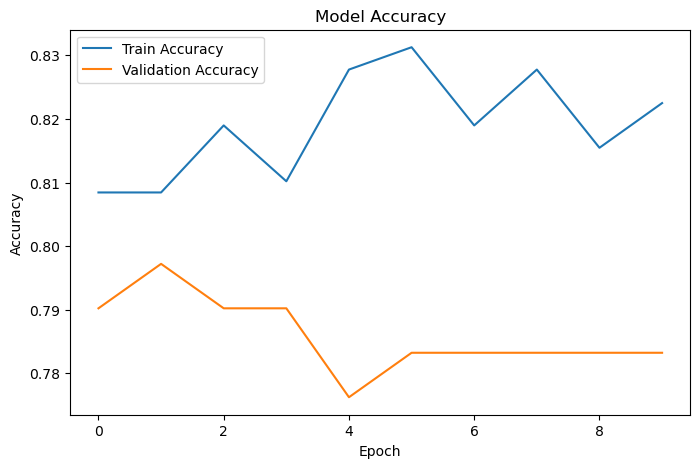

In [34]:
# Accuracy and Loss Graphs

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

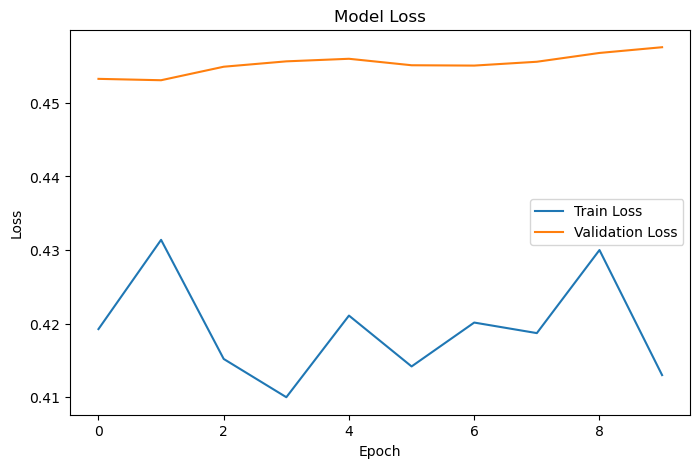

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

In [36]:
# Model Result Comment

print("Model Evaluation Result")
print("-----------------------")
print("Loss:", loss)
print("Accuracy:", accuracy)

if accuracy >= 0.75:
    print("The model achieved a good classification performance.")
else:
    print("The model performance can be improved.")

Model Evaluation Result
-----------------------
Loss: 0.4420746862888336
Accuracy: 0.7877094745635986
The model achieved a good classification performance.


### Conclusion

In this project, a Deep Learning Classification model was developed using the Titanic dataset and the Keras Sequential Neural Network architecture.

Several data preprocessing techniques were applied, including missing value handling, categorical variable encoding, feature selection, train-test splitting, and feature scaling.

A Deep Neural Network consisting of multiple Dense and Dropout layers was created to predict passenger survival outcomes.

The model achieved approximately 79% accuracy on the test dataset, demonstrating acceptable classification performance. The confusion matrix and classification report showed that the model performed better in predicting passengers who did not survive compared to passengers who survived.

Training and validation accuracy graphs indicated stable learning behavior, while the loss graphs suggested that the model did not suffer from severe overfitting.

Overall, the results demonstrate that Keras-based Deep Learning techniques can effectively classify Titanic passenger survival outcomes using demographic and travel-related features.